### Problem 1

#### 代码

In [11]:
# Problem 1

## (a)

import numpy as np

def Kn(n: int) -> np.ndarray:
    K = 2*np.eye(n, dtype=float) + -1*np.eye(n, k=1, dtype=float) + -1*np.eye(n, k=-1, dtype=float)
    return K

def u_j(n: int, j: int) -> np.ndarray:
    u = np.zeros(n, dtype=float)
    for i in range(1, n+1):
        if i <= j:
            u[i-1] = (n + 1 - j) * i
        else:
            u[i-1] = (n + 1 - i) * j
    return u

def Kn_times_u_j(n: int, j: int) -> np.ndarray:
    K = Kn(n)
    u = u_j(n, j)
    return K @ u

n = 5
for j in range(1, n+1):
    y = Kn_times_u_j(n, j)
    print(f"j={j}, K_n u_j = {y}")

j=1, K_n u_j = [6. 0. 0. 0. 0.]
j=2, K_n u_j = [0. 6. 0. 0. 0.]
j=3, K_n u_j = [0. 0. 6. 0. 0.]
j=4, K_n u_j = [0. 0. 0. 6. 0.]
j=5, K_n u_j = [0. 0. 0. 0. 6.]


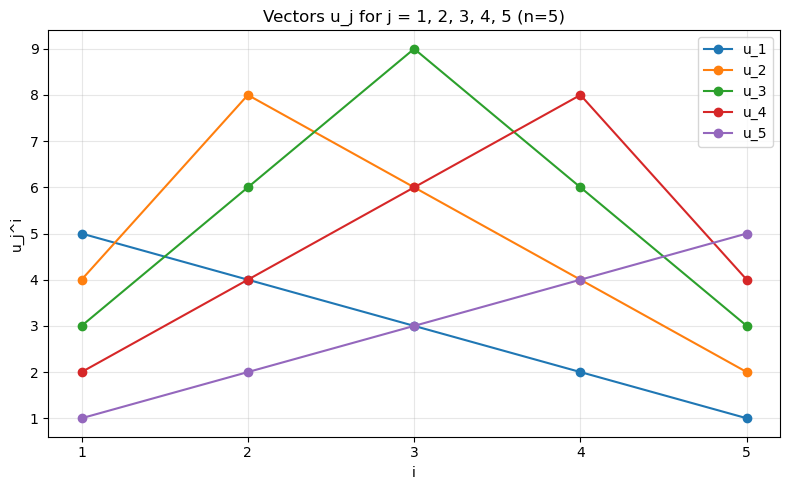

In [12]:
## (b)
import matplotlib.pyplot as plt

n = 5
x = np.arange(1, n + 1)

plt.figure(figsize=(8, 5))
for j in range(1, n + 1):
    plt.plot(x, u_j(n, j), marker='o', label=f'u_{j}')

plt.title('Vectors u_j for j = 1, 2, 3, 4, 5 (n=5)')
plt.xlabel('i')
plt.ylabel('u_j^i')
plt.xticks(x)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Problem 2

#### (a) 数学解法

代入 $(\mathbf v_k)_j=\omega^{(j-1)k}$：

$
\begin{aligned}
(C_n\mathbf v_k)_j
&=2\omega^{(j-1)k}-\omega^{(j-2)k}-\omega^{jk} \\
&=(2-\omega^k-\omega^{-k})\omega^{(j-1)k}
\end{aligned}
$

因此 $ C_n\mathbf v_k = (2-\omega^k-\omega^{-k})\mathbf v_k $

故 $ \mathbf v_k \text{ 是 } C_n \text{ 的特征向量} $

In [16]:
# Problem 2

## (a) 代码解法

def Cn(n: int) -> np.ndarray:
    C = 2*np.eye(n, dtype=complex) + -1*np.eye(n, k=1, dtype=complex) + -1*np.eye(n, k=-1, dtype=complex)
    C[0, -1] = -1
    C[-1, 0] = -1
    return C

def v_k(n: int, k: int) -> np.ndarray:
    omega = np.exp(2j * np.pi / n)
    i = np.arange(n)
    return omega ** (k * i)

# Numerical verification of the eigenvector statement
n = 20
C = Cn(n)
omega = np.exp(2j * np.pi / n)

for k in range(n):
    vk = v_k(n, k)
    lam_k = 2 - omega**k - omega**(-k)
    residual = np.linalg.norm(C @ vk - lam_k * vk)
    print(f"k={k}, lambda={lam_k.real:.10f}, residual={residual:.2e}")

k=0, lambda=0.0000000000, residual=0.00e+00
k=1, lambda=0.0978869674, residual=1.95e-15
k=2, lambda=0.3819660113, residual=4.07e-15
k=3, lambda=0.8244294954, residual=5.95e-15
k=4, lambda=1.3819660113, residual=7.51e-15
k=5, lambda=2.0000000000, residual=9.81e-15
k=6, lambda=2.6180339887, residual=1.38e-14
k=7, lambda=3.1755705046, residual=1.74e-14
k=8, lambda=3.6180339887, residual=1.34e-14
k=9, lambda=3.9021130326, residual=1.99e-14
k=10, lambda=4.0000000000, residual=2.46e-14
k=11, lambda=3.9021130326, residual=2.23e-14
k=12, lambda=3.6180339887, residual=2.33e-14
k=13, lambda=3.1755705046, residual=3.08e-14
k=14, lambda=2.6180339887, residual=2.73e-14
k=15, lambda=2.0000000000, residual=2.91e-14
k=16, lambda=1.3819660113, residual=2.66e-14
k=17, lambda=0.8244294954, residual=3.20e-14
k=18, lambda=0.3819660113, residual=3.73e-14
k=19, lambda=0.0978869674, residual=4.82e-14


### (b) 求特征值并判断是否全为正

#### 数学解法

由于 $ \omega^k = e^{\frac{2\pi i k}{n}}$

因此 $\omega^k + \omega^{-k} = 2\cos\left(\frac{2\pi k}{n}\right)$

于是 $\lambda_k = 2-2\cos\left(\frac{2\pi k}{n}\right) $

利用恒等式 $1-\cos\theta = 2\sin^2(\theta/2)$

可得$v\lambda_k = 4\sin^2\left(\frac{\pi k}{n}\right)v$

因此$\lambda_k = 4\sin^2\left(\frac{\pi k}{n}\right),\qquad k=0,1,\dots,n-1$

- 当 $k=0,\ \lambda_0 = 4\sin^2(0) = 0$

- 当 $k=1,\dots,n-1\ \sin\left(\frac{\pi k}{n}\right) \neq 0 \ \lambda_k > 0$

In [17]:
## (b)

# Check eigenvalues numerically and compare with the closed form
n = 8
C = Cn(n)

eig_numeric = np.sort(np.real_if_close(np.linalg.eigvals(C)))
k = np.arange(n)
eig_formula = np.sort(2 - 2*np.cos(2*np.pi*k/n))

print("numeric eigenvalues:", np.round(eig_numeric, 10))
print("formula eigenvalues:", np.round(eig_formula, 10))
print("max |difference|:", np.max(np.abs(eig_numeric - eig_formula)))

is_strictly_positive = np.all(eig_numeric > 1e-12)
is_nonnegative = np.all(eig_numeric >= -1e-12)
print("all eigenvalues strictly positive?", is_strictly_positive)
print("all eigenvalues nonnegative?", is_nonnegative)
print("minimum eigenvalue:", np.min(eig_numeric))

numeric eigenvalues: [-0.          0.58578644  0.58578644  2.          2.          3.41421356
  3.41421356  4.        ]
formula eigenvalues: [0.         0.58578644 0.58578644 2.         2.         3.41421356
 3.41421356 4.        ]
max |difference|: 1.5543122344752192e-15
all eigenvalues strictly positive? False
all eigenvalues nonnegative? True
minimum eigenvalue: -8.847769798245248e-17


### Problem 3

$
B_3=
\begin{bmatrix}
1 & -1 & 0\\
-1 & 2 & -1\\
0 & -1 & 1
\end{bmatrix}
$

并且 $B_3u=f$

即

$
\begin{cases}
u_1-u_2=-1\\
-u_1+2u_2-u_3=0\\
-u_2+u_3=1
\end{cases}
$

显然其解不唯一，

令 $ u_2=t $

则

$
u=
\begin{bmatrix}
t-1\\
t\\
t+1
\end{bmatrix},
\quad t\in\mathbb{R}
$

也可以写为

$
u=
\begin{bmatrix}
-1\\0\\1
\end{bmatrix}
+
t
\begin{bmatrix}
1\\1\\1
\end{bmatrix}
$

其中 $ \begin{bmatrix}1\\1\\1\end{bmatrix} $

表示系统整体平移，不会改变弹簧伸长，因此不会产生内力。